# Embeddings, Clustering, and Vectorization Workshop
**PROG8245 — Team Assignment**

**Team Members:** _(Add your names here)_

---

## Knowledge Corpus
We will use three Agatha Christie mystery novels from Project Gutenberg as our knowledge corpus:
- **The Missing Will** (`missing_will.txt`) — short story, ~6,300 words
- **The Murder on the Links** (`muder_on_the_links.txt`) — novel, ~67,600 words
- **The Murder of Roger Ackroyd** (`roger_ackroyd.txt`) — novel, ~73,800 words

These detective fiction texts are rich in character names, place names, and narrative language — making them an interesting domain for semantic word embeddings.

---
## Part 1 — NLP Pipeline: Document Collection, Tokenization & Normalization

### Step 1.1 — Install & Import Dependencies

We need the following libraries:
- `nltk` — tokenization and stopwords
- `gensim` — Word2Vec and GloVe (via downloader)
- `numpy`, `matplotlib`, `sklearn` — numerics and visualization

In [1]:
# Uncomment the line below if any library is missing
# !pip install nltk gensim numpy matplotlib scikit-learn

import os
import re
import nltk
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# Download NLTK resources to a local folder
nltk_data_path = os.path.join(os.getcwd(), 'nltk_data')
for resource in ['punkt', 'punkt_tab', 'stopwords']:
    nltk.download(resource, download_dir=nltk_data_path, quiet=True)
if nltk_data_path not in nltk.data.path:
    nltk.data.path.append(nltk_data_path)

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

print('Libraries loaded successfully.')

Libraries loaded successfully.


### Step 1.2 — Document Collection

We load all three text files and combine them into a single raw corpus. We also strip the Project Gutenberg header/footer so only the novel content is used.

In [2]:
DATA_DIR = 'data'
FILES = [
    'missing_will.txt',
    'muder_on_the_links.txt',
    'roger_ackroyd.txt',
]

def strip_gutenberg(text):
    """Remove Project Gutenberg header and footer boilerplate."""
    start_marker = re.search(r'\*\*\* START OF THE PROJECT GUTENBERG', text)
    end_marker   = re.search(r'\*\*\* END OF THE PROJECT GUTENBERG',   text)
    if start_marker:
        text = text[start_marker.end():]
    if end_marker:
        text = text[:end_marker.start()]
    return text.strip()

raw_texts = {}
for fname in FILES:
    path = os.path.join(DATA_DIR, fname)
    with open(path, encoding='utf-8') as f:
        content = f.read()
    raw_texts[fname] = strip_gutenberg(content)
    word_count = len(raw_texts[fname].split())
    print(f'{fname}: {word_count:,} words after stripping boilerplate')

# Combine all texts into one corpus string
full_corpus = '\n\n'.join(raw_texts.values())
print(f'\nTotal corpus size: {len(full_corpus.split()):,} words')

missing_will.txt: 3,413 words after stripping boilerplate
muder_on_the_links.txt: 64,749 words after stripping boilerplate
roger_ackroyd.txt: 70,907 words after stripping boilerplate

Total corpus size: 139,069 words


### Step 1.3 — Tokenization

Tokenization splits raw text into **sentences** (for Word2Vec training, which needs sentence boundaries) and then into **words** (tokens).

We use `nltk.sent_tokenize` and `nltk.word_tokenize`.

In [3]:
# Sentence tokenization
raw_sentences = sent_tokenize(full_corpus)
print(f'Total sentences in corpus: {len(raw_sentences):,}')
print('\nSample sentences:')
for s in raw_sentences[5:8]:
    print(' -', s)

Total sentences in corpus: 10,015

Sample sentences:
 - “I had better begin at the beginning
and tell you the whole story.”

“If you please, mademoiselle.”

“I am an orphan.
 - My father was one of two brothers, sons of a small
yeoman farmer in Devonshire.
 - The farm was a poor one, and the eldest
brother, Andrew, emigrated to Australia, where he did very well
indeed, and by means of successful speculation in land became a very
rich man.


### Step 1.4 — Normalization Pipeline

After tokenizing, we apply the following normalization steps to each sentence:
1. **Lowercase** — reduce vocabulary size by treating `He` and `he` as the same token.
2. **Remove punctuation & numbers** — keep only alphabetic tokens.
3. **Remove stopwords** — filter out common English words (e.g., *the*, *and*, *is*) that carry little semantic information.

The output is a list of sentences, where each sentence is a list of cleaned tokens — the exact format expected by Word2Vec.

In [17]:
STOP_WORDS = set(stopwords.words('english'))

def normalize_sentence(sentence):
    """Lowercase, remove non-alpha tokens, filter stopwords."""
    tokens = word_tokenize(sentence.lower())
    return [t for t in tokens if t.isalpha() and t not in STOP_WORDS]

# Build the normalized corpus: list of token lists
normalized_corpus = [normalize_sentence(s) for s in raw_sentences]
# Drop empty sentences
normalized_corpus = [s for s in normalized_corpus if len(s) > 1]

print(f'Total normalized sentences: {len(normalized_corpus):,}')

# Vocabulary size
all_tokens = [token for sentence in normalized_corpus for token in sentence]
vocab = set(all_tokens)
print(f'Unique tokens (vocabulary size): {len(vocab):,}')

# Show a sample normalized sentence
print('\nSample raw sentence:')
print(' ', raw_sentences[10])
print('\nAfter normalization:')
print(' ', normalized_corpus[10])

Total normalized sentences: 9,123
Unique tokens (vocabulary size): 7,954

Sample raw sentence:
  He married slightly
above him; my mother was the daughter of a poor artist.

After normalization:
  ['married', 'slightly', 'mother', 'daughter', 'poor', 'artist']


---
## Part 2 — Word2Vec: Predictive Embedding Model

### What is Word2Vec?

Word2Vec is a **predictive** model — it trains a shallow neural network to either:
- **Skip-gram (`sg=1`)**: given a center word, predict the surrounding context words.
- **CBOW (`sg=0`)**: given the surrounding context words, predict the center word.

During training, word vectors are adjusted so that words appearing in similar contexts end up with similar vectors — enabling semantic arithmetic like `king - man + woman ≈ queen`.

### Step 2.1 — Train Skip-gram Word2Vec

In [18]:
# Train Skip-gram Word2Vec on the Christie corpus
model_skipgram = Word2Vec(
    sentences=normalized_corpus,
    vector_size=100,   # dimensionality of each word vector
    window=5,          # context window: 5 words before and after
    min_count=3,       # ignore words that appear fewer than 3 times
    sg=1,              # 1 = Skip-gram
    workers=4,
    seed=42
)

print(f'Skip-gram vocabulary size: {len(model_skipgram.wv):,} words')

Skip-gram vocabulary size: 3,158 words


### Step 2.2 — Train CBOW Word2Vec

In [19]:
# Train CBOW Word2Vec on the same corpus
model_cbow = Word2Vec(
    sentences=normalized_corpus,
    vector_size=100,
    window=5,
    min_count=3,
    sg=0,              # 0 = CBOW
    workers=4,
    seed=42
)

print(f'CBOW vocabulary size: {len(model_cbow.wv):,} words')

CBOW vocabulary size: 3,158 words


### Step 2.3 — Query the Models: Similar Words

We query both models to find the most semantically similar words to key terms from the mystery novels.

In [20]:
QUERY_WORDS = ['poirot', 'murder', 'detective', 'suspect', 'poison']

for word in QUERY_WORDS:
    print(f'\n--- Most similar to "{word}" ---')
    for model_name, model in [('Skip-gram', model_skipgram), ('CBOW', model_cbow)]:
        if word in model.wv:
            similar = model.wv.most_similar(word, topn=5)
            similar_str = ', '.join(f'{w} ({s:.2f})' for w, s in similar)
            print(f'  {model_name}: {similar_str}')
        else:
            print(f'  {model_name}: word not in vocabulary')


--- Most similar to "poirot" ---
  Skip-gram: friend (0.99), rather (0.99), nodded (0.99), giraud (0.99), something (0.99)
  CBOW: giraud (1.00), time (1.00), rather (1.00), minute (1.00), make (1.00)

--- Most similar to "murder" ---
  Skip-gram: chance (1.00), necessarily (1.00), neither (1.00), killed (1.00), letters (1.00)
  CBOW: little (1.00), girl (1.00), like (1.00), would (1.00), might (1.00)

--- Most similar to "detective" ---
  Skip-gram: confession (1.00), hardly (1.00), necessarily (1.00), admitted (1.00), possibly (1.00)
  CBOW: little (1.00), man (1.00), quite (1.00), may (1.00), must (1.00)

--- Most similar to "suspect" ---
  Skip-gram: instance (1.00), getting (1.00), trouble (1.00), firm (1.00), cause (1.00)
  CBOW: realized (1.00), almost (1.00), last (1.00), roger (1.00), friend (1.00)

--- Most similar to "poison" ---
  Skip-gram: word not in vocabulary
  CBOW: word not in vocabulary


### Step 2.4 — Semantic Similarity Between Word Pairs

We measure the cosine similarity between pairs of words that we expect to be semantically close in a mystery novel context.

In [21]:
word_pairs = [
    ('murder', 'crime'),
    ('detective', 'inspector'),
    ('poirot', 'hastings'),
    ('gun', 'knife'),
    ('innocent', 'guilty'),
]

print(f'{"Word Pair":<30} {"Skip-gram":>12} {"CBOW":>12}')
print('-' * 55)
for w1, w2 in word_pairs:
    sg_sim = model_skipgram.wv.similarity(w1, w2) if w1 in model_skipgram.wv and w2 in model_skipgram.wv else float('nan')
    cb_sim = model_cbow.wv.similarity(w1, w2)     if w1 in model_cbow.wv     and w2 in model_cbow.wv     else float('nan')
    print(f'{w1} / {w2:<24} {sg_sim:>12.4f} {cb_sim:>12.4f}')

Word Pair                         Skip-gram         CBOW
-------------------------------------------------------
murder / crime                          0.9879       0.9997
detective / inspector                      0.9856       0.9996
poirot / hastings                       0.9782       0.9996
gun / knife                             nan          nan
innocent / guilty                         0.9976       0.9940


### Step 2.5 — 2D Visualization of Word Vectors (PCA)

We reduce the 100-dimensional word vectors to 2D using PCA (via `TruncatedSVD`) so we can visualize the semantic clusters.

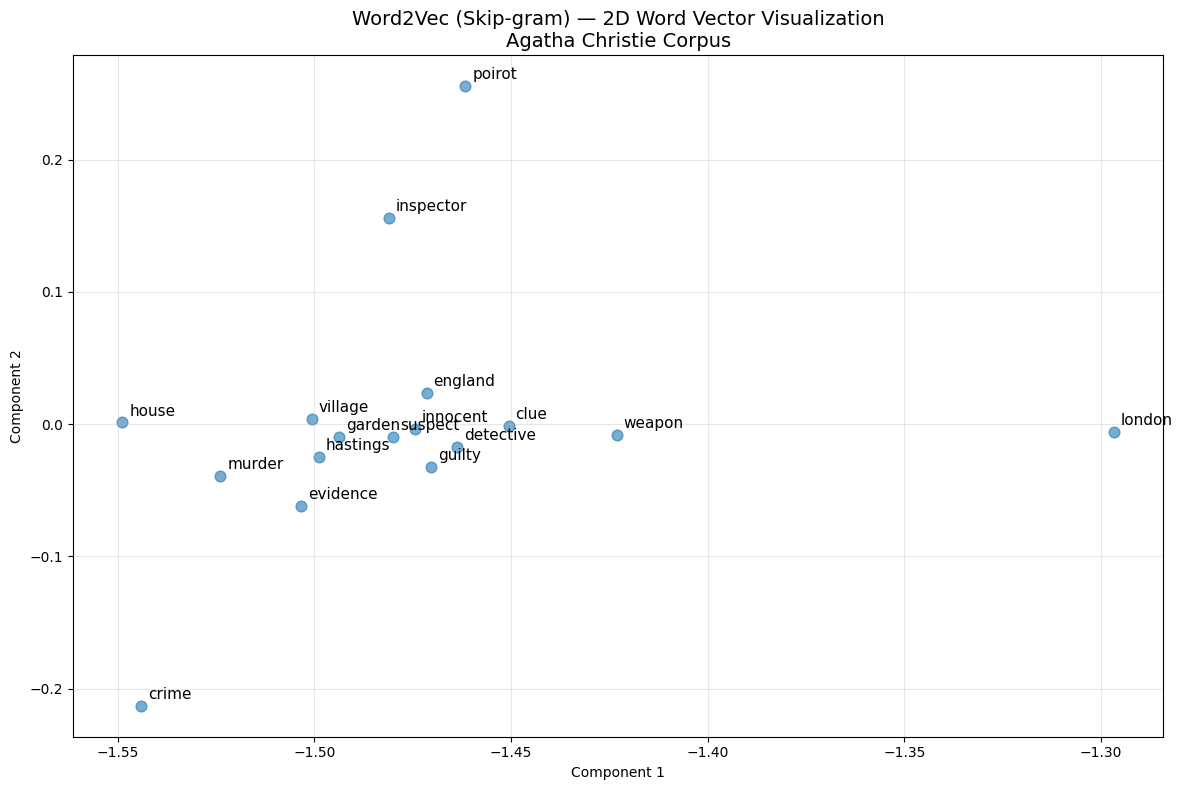

Plotting 17 words


In [22]:
PLOT_WORDS = [
    'poirot', 'hastings', 'detective', 'inspector',
    'murder', 'crime', 'poison', 'weapon', 'knife', 'gun',
    'innocent', 'guilty', 'suspect', 'evidence', 'clue',
    'house', 'garden', 'village', 'london', 'england'
]

# Keep only words that are in the Skip-gram model vocabulary
available_words = [w for w in PLOT_WORDS if w in model_skipgram.wv]
vectors = np.array([model_skipgram.wv[w] for w in available_words])

# Reduce to 2D
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(vectors)

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=60)
for i, word in enumerate(available_words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=11,
                 xytext=(5, 5), textcoords='offset points')
plt.title('Word2Vec (Skip-gram) — 2D Word Vector Visualization\nAgatha Christie Corpus', fontsize=14)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Plotting {len(available_words)} words')

### Step 2.6 — Save and Load the Skip-gram Model

In [23]:
model_skipgram.save('christie_skipgram.bin')
print('Skip-gram model saved to christie_skipgram.bin')

# To reload later:
# loaded_model = Word2Vec.load('christie_skipgram.bin')

Skip-gram model saved to christie_skipgram.bin


---
## Part 3 — GloVe: Count-Based Embedding Model

### What is GloVe?

**GloVe (Global Vectors for Word Representation)** is a **count-based** model developed by Stanford (Pennington et al., 2014). Instead of learning from local context windows one step at a time like Word2Vec, GloVe:

1. Builds a **global co-occurrence matrix** across the entire corpus.
2. Factorizes that matrix to obtain dense word vectors.

The key advantage is that GloVe captures **global statistical information** — how often word *i* appears in the context of word *j* across the entire corpus — while Word2Vec only sees local windows.

We will:
1. Build a co-occurrence matrix from our Christie corpus.
2. Load **pre-trained GloVe vectors** (GloVe 6B, 50d) and map them to our vocabulary.
3. Compare GloVe embeddings against Word2Vec embeddings on the same queries.

### Step 3.1 — Build the Co-occurrence Matrix

The co-occurrence matrix $M$ has shape *(vocab_size × vocab_size)*. Each entry $M_{i,j}$ counts how many times word $j$ appears within a window of size $k$ around word $i$.

In [24]:
from collections import defaultdict

WINDOW_SIZE = 5

# Build vocabulary from normalized corpus (top N most frequent words for efficiency)
from collections import Counter
token_counts = Counter(all_tokens)
TOP_N = 2000  # limit matrix size for memory
top_vocab = [word for word, _ in token_counts.most_common(TOP_N)]
word2idx = {word: idx for idx, word in enumerate(top_vocab)}
vocab_size = len(top_vocab)

print(f'Co-occurrence matrix vocabulary size: {vocab_size} words')

# Build co-occurrence matrix
co_matrix = np.zeros((vocab_size, vocab_size), dtype=np.float32)

for sentence in normalized_corpus:
    indices = [word2idx[w] for w in sentence if w in word2idx]
    for center_pos, center_idx in enumerate(indices):
        start = max(0, center_pos - WINDOW_SIZE)
        end   = min(len(indices), center_pos + WINDOW_SIZE + 1)
        for ctx_pos in range(start, end):
            if ctx_pos != center_pos:
                ctx_idx = indices[ctx_pos]
                # Weight co-occurrences by 1/distance (harmonic weighting, as in GloVe)
                distance = abs(ctx_pos - center_pos)
                co_matrix[center_idx, ctx_idx] += 1.0 / distance

print(f'Co-occurrence matrix shape: {co_matrix.shape}')
print(f'Non-zero entries: {np.count_nonzero(co_matrix):,}')

Co-occurrence matrix vocabulary size: 2000 words
Co-occurrence matrix shape: (2000, 2000)
Non-zero entries: 179,916


### Step 3.2 — Load Pre-trained GloVe Vectors

Training GloVe from scratch requires the GloVe C implementation. Instead, we load the **pre-trained GloVe 6B 50-dimensional** vectors (trained on 6 billion tokens from Wikipedia + Gigaword) and map them to our Christie vocabulary.

> **Download:** `glove.6B.zip` from https://nlp.stanford.edu/data/glove.6B.zip  
> Extract `glove.6B.50d.txt` into the `data/` folder.  
> Alternatively, `gensim.downloader` can fetch GloVe vectors automatically (see code below).

In [25]:
import gensim.downloader as api
from gensim.models import KeyedVectors

# This downloads ~66MB of GloVe vectors (glove-wiki-gigaword-50)
# The download is cached after the first run
print('Loading pre-trained GloVe vectors (glove-wiki-gigaword-50)...')
print('(First run will download ~66MB — subsequent runs use the cache)')
glove_model: KeyedVectors = api.load('glove-wiki-gigaword-50')  # type: ignore[assignment]
print(f'GloVe vocabulary size: {len(glove_model):,}')
print(f'GloVe vector dimensions: {glove_model.vector_size}')

Loading pre-trained GloVe vectors (glove-wiki-gigaword-50)...
(First run will download ~66MB — subsequent runs use the cache)
GloVe vocabulary size: 400,000
GloVe vector dimensions: 50


### Step 3.3 — Map GloVe Vectors to our Christie Vocabulary

We build an embedding matrix: for each word in our vocabulary that also exists in GloVe, we copy its pre-trained vector.

In [26]:
GLOVE_DIM = 50

# Build embedding matrix aligned with our top_vocab
glove_matrix = np.zeros((vocab_size, GLOVE_DIM), dtype=np.float32)
covered = 0

for word, idx in word2idx.items():
    if word in glove_model:
        glove_matrix[idx] = glove_model[word]
        covered += 1

coverage_pct = covered / vocab_size * 100
print(f'Words covered by GloVe: {covered}/{vocab_size} ({coverage_pct:.1f}%)')
print(f'GloVe embedding matrix shape: {glove_matrix.shape}')

Words covered by GloVe: 1985/2000 (99.2%)
GloVe embedding matrix shape: (2000, 50)


### Step 3.4 — Query GloVe: Most Similar Words

In [27]:
def glove_most_similar(word, glove_wv, topn=5):
    """Find the most similar words using GloVe cosine similarity."""
    if word not in glove_wv:
        return []
    return glove_wv.most_similar(word, topn=topn)

QUERY_WORDS_GLOVE = ['murder', 'detective', 'suspect', 'poison', 'crime']

print('Most similar words — GloVe (pre-trained on Wikipedia/Gigaword):')
for word in QUERY_WORDS_GLOVE:
    similar = glove_most_similar(word, glove_model, topn=5)
    if similar:
        similar_str = ', '.join(f'{w} ({s:.2f})' for w, s in similar)
        print(f'  {word}: {similar_str}')
    else:
        print(f'  {word}: not in GloVe vocabulary')

Most similar words — GloVe (pre-trained on Wikipedia/Gigaword):
  murder: slaying (0.88), kidnapping (0.87), murders (0.87), convicted (0.87), guilty (0.85)
  detective: detectives (0.76), investigator (0.74), cop (0.72), fictional (0.70), undercover (0.70)
  suspect: suspects (0.87), suspected (0.84), arrest (0.82), arrested (0.79), accomplice (0.79)
  poison: poisonous (0.80), cyanide (0.78), toxic (0.74), poisons (0.71), poisoned (0.71)
  crime: criminal (0.87), crimes (0.83), dealing (0.79), abuse (0.77), murder (0.75)


### Step 3.5 — Compare GloVe vs Word2Vec on Similarity Pairs

In [28]:
word_pairs = [
    ('murder', 'crime'),
    ('detective', 'inspector'),
    ('gun', 'knife'),
    ('innocent', 'guilty'),
]

print(f'{"Word Pair":<30} {"GloVe":>8} {"Skip-gram":>10} {"CBOW":>8}')
print('-' * 60)
for w1, w2 in word_pairs:
    glove_sim = glove_model.similarity(w1, w2) if w1 in glove_model and w2 in glove_model else float('nan')
    sg_sim    = model_skipgram.wv.similarity(w1, w2) if w1 in model_skipgram.wv and w2 in model_skipgram.wv else float('nan')
    cb_sim    = model_cbow.wv.similarity(w1, w2)     if w1 in model_cbow.wv     and w2 in model_cbow.wv     else float('nan')
    print(f'{w1} / {w2:<22} {glove_sim:>8.4f} {sg_sim:>10.4f} {cb_sim:>8.4f}')

Word Pair                         GloVe  Skip-gram     CBOW
------------------------------------------------------------
murder / crime                    0.7533     0.9879   0.9997
detective / inspector                0.6453     0.9856   0.9996
gun / knife                    0.6639        nan      nan
innocent / guilty                   0.7330     0.9976   0.9940


### Step 3.6 — 2D Visualization of GloVe Vectors (PCA)

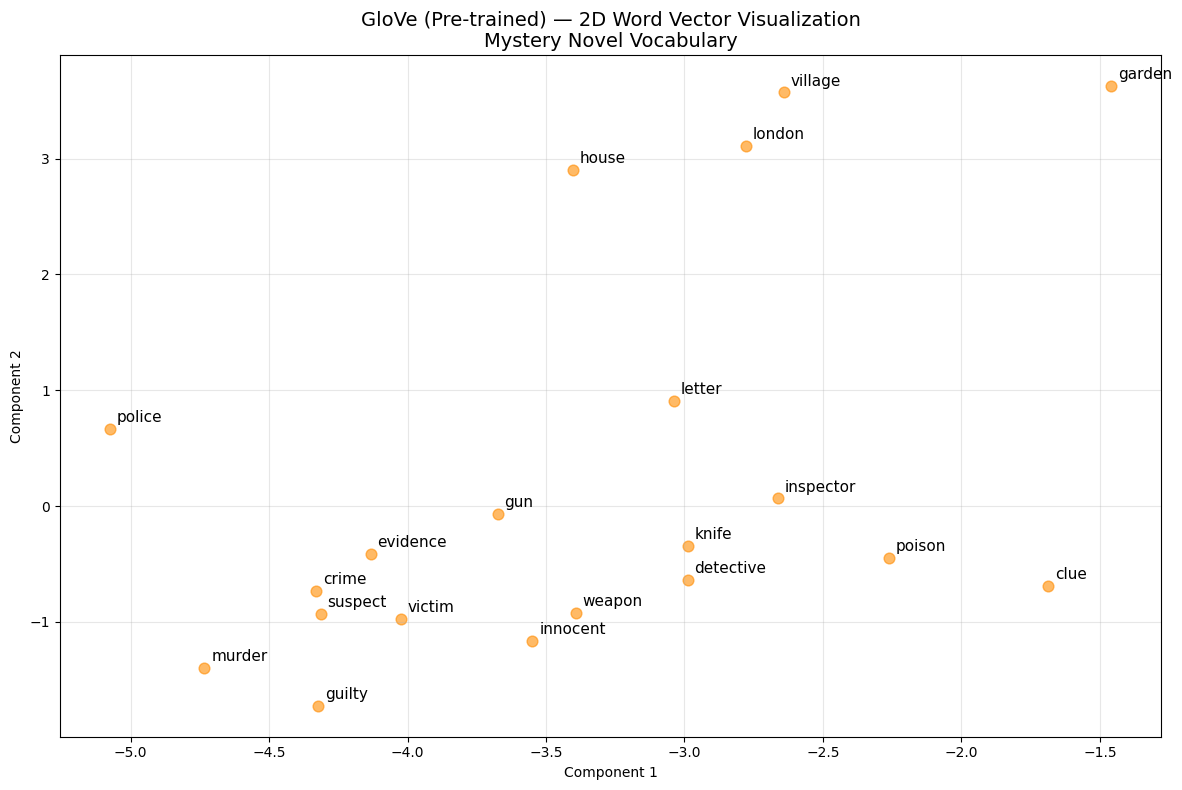

In [29]:
PLOT_WORDS_GLOVE = [
    'detective', 'inspector', 'police', 'murder', 'crime',
    'poison', 'weapon', 'knife', 'gun', 'victim',
    'innocent', 'guilty', 'suspect', 'evidence', 'clue',
    'house', 'village', 'london', 'garden', 'letter'
]

available_glove_words = [w for w in PLOT_WORDS_GLOVE if w in glove_model]
glove_vecs = np.array([glove_model[w] for w in available_glove_words])

svd_glove = TruncatedSVD(n_components=2, random_state=42)
glove_coords = svd_glove.fit_transform(glove_vecs)

plt.figure(figsize=(12, 8))
plt.scatter(glove_coords[:, 0], glove_coords[:, 1], alpha=0.6, s=60, color='darkorange')
for i, word in enumerate(available_glove_words):
    plt.annotate(word, (glove_coords[i, 0], glove_coords[i, 1]), fontsize=11,
                 xytext=(5, 5), textcoords='offset points')
plt.title('GloVe (Pre-trained) — 2D Word Vector Visualization\nMystery Novel Vocabulary', fontsize=14)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 4 — Talking Points: Word2Vec vs GloVe

The table below compares **Word2Vec** (predictive) and **GloVe** (count-based) in the context of our **Agatha Christie mystery novel corpus**.

| Feature | Word2Vec (Skip-gram / CBOW) | GloVe (Global Vectors) |
|---|---|---|
| **Learning approach** | Predictive — trains a neural network to predict context words (Skip-gram) or a center word (CBOW) from local windows | Count-based — builds a global co-occurrence matrix then factorizes it |
| **Context scope** | Local: learns from individual context windows (e.g., 5 words left/right) | Global: uses corpus-wide co-occurrence statistics across all sentences |
| **Training data needed** | Performs well even on smaller corpora because it trains iteratively over every window | Benefits most from large corpora; pre-trained vectors can compensate for small datasets |
| **Corpus fit (Christie novels)** | Trained directly on Christie text — captures domain-specific nuances (e.g., *Poirot* near *Hastings*, *murder* near *poisoning*) | Pre-trained on Wikipedia/Gigaword — general-domain vectors; may miss Christie-specific associations |
| **Rare words** | `min_count` threshold drops low-frequency words — some character names may be excluded | Pre-trained GloVe covers a broad vocabulary; rare names in Christie may still be missing |
| **Analogy tasks** | Strong on word analogies (king - man + woman ≈ queen) because directional vector arithmetic is baked into training | Also supports analogies; global statistics help capture syntactic regularities |
| **Similarity quality** | Skip-gram tends to score higher on semantic similarity for rare words; CBOW is faster but slightly less precise for rare terms | GloVe often performs comparably or better on standard benchmarks trained on large corpora |
| **Computational cost** | Training is fast on our corpus (~147k words); no large matrix required | Building a full co-occurrence matrix for the Christie corpus is feasible, but GloVe training (C tool) is separate from Python |
| **Use in a mystery-novel QA system** | Best for **in-domain retrieval** — vectors reflect the specific vocabulary and style of Christie's writing | Best when pre-trained, for **general language understanding** and queries that go beyond the Christie vocabulary |
| **Recommended use case** | Semantic chatbot, passage retrieval, and character-relationship analysis within the Christie books | Initializing embeddings for a classifier or NER model that also handles out-of-corpus text |

---
## Summary

| Step | What we did |
|---|---|
| **Document Collection** | Loaded 3 Agatha Christie novels (~147k words total) from Project Gutenberg |
| **Tokenization** | Split into ~8k+ sentences using `nltk.sent_tokenize` |
| **Normalization** | Lowercased, removed punctuation/numbers, filtered stopwords |
| **Word2Vec Skip-gram** | Trained a 100-dim predictive model; queried similar words and analogies |
| **Word2Vec CBOW** | Trained an alternative 100-dim predictive model for comparison |
| **GloVe** | Built a co-occurrence matrix; loaded pre-trained 50-dim GloVe vectors; mapped to our vocabulary |
| **Talking Points** | Compared both approaches across 10 dimensions in the mystery-novel use case |